# Tune MLP dropout for RSC head-direction decoding

This notebook uses the fixed temporal train/validation/test split from the original MLP decoder. It tunes one hyperparameter: the dropout rate. Each candidate rate gets a fresh model, and the test set is used only after the best rate has been selected.


## What this notebook teaches

- **Hyperparameter tuning（超参数调优）** using a validation set.
- Comparing several dropout rates with the same train/validation split.
- Saving the best epoch for each candidate.
- Selecting the dropout rate using validation circular HD error.
- Evaluating the selected model once on an untouched test set.

The test set is never used to choose the dropout rate or the training epoch.


In [1]:
# If imports fail, run this in a terminal from the project folder:
# pip install -r requirements.txt

from pathlib import Path
import math
import random

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

plt.style.use("seaborn-v0_8-whitegrid")
torch.set_float32_matmul_precision("high")

def seed_everything(seed=7):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(7)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Choose one session and one cylinder window

The MATLAB script used `sessionList.xlsx` plus robust-cell tables to loop over many sessions. For learning PyTorch, start with one known session and all accepted CNMF-E components. Later, you can add robust-cell selection and cross-session loops.

In [2]:
DATA_ROOT = Path(r"D:/Shiyun_RSC_1p")
SESSION_NAME = "STIM1_2026_01_22_constantCue_acquisition"
SESSION_DIR = DATA_ROOT / SESSION_NAME

SESSION_DATA = SESSION_DIR / "sessionData.mat"
CNMFE_HDF5 = SESSION_DIR / "pipeline_cnmfe_results_2026-01-24_08-18.hdf5"

# MATLAB window labels: 0=pre-rotation, 1=post-rotation, 2=dark in Python indexing.
WINDOW_INDEX = 0
WINDOW_NAMES = ["pre rotation", "post rotation", "dark"]

# Set to None for no speed filtering in the first learning pass.
# MATLAB used speed_cri.of after lag alignment; you can add that later.
MIN_SPEED_PX_PER_S = None

assert SESSION_DATA.exists(), SESSION_DATA
assert CNMFE_HDF5.exists(), CNMFE_HDF5
SESSION_DATA, CNMFE_HDF5

(WindowsPath('D:/Shiyun_RSC_1p/STIM1_2026_01_22_constantCue_acquisition/sessionData.mat'),
 WindowsPath('D:/Shiyun_RSC_1p/STIM1_2026_01_22_constantCue_acquisition/pipeline_cnmfe_results_2026-01-24_08-18.hdf5'))

## MATLAB v7.3/HDF5 helpers

MATLAB v7.3 files are HDF5 files. Arrays are often stored with dimensions reversed relative to MATLAB display, so the helper below transposes 2D numeric datasets by default.

In [3]:
def read_matlab_h5_array(group, key, transpose_2d=True):
    """Read a numeric dataset from a MATLAB v7.3 struct group."""
    arr = np.array(group[key])
    arr = np.squeeze(arr)
    if transpose_2d and arr.ndim == 2:
        arr = arr.T
    return arr


def describe_h5_group(group, max_items=30):
    rows = []
    for key in list(group.keys())[:max_items]:
        obj = group[key]
        shape = getattr(obj, "shape", "")
        dtype = getattr(obj, "dtype", "")
        rows.append((key, shape, dtype))
    return pd.DataFrame(rows, columns=["key", "shape", "dtype"])


with h5py.File(SESSION_DATA, "r") as f:
    print(list(f.keys()))
    display(describe_h5_group(f["sessionData"]))
    display(describe_h5_group(f["sessionData"]["of"]))

['#refs#', '#subsystem#', 'sessionData']


,key,shape,dtype
0,Afs,"(4374, 37689)",float64
1,S,"(4374, 37689)",float64
2,calcium_time,"(37689, 1)",float64
3,idx_components,"(461, 1)",float64
4,maze,,
5,of,,
6,raw_C,"(4374, 37689)",float64


,key,shape,dtype
0,dark_flag,"(1, 1)",uint8
1,hd,"(37689, 1)",float64
2,raw_coord,"(2, 37689)",float64
3,segment_time,"(2, 4)",float64


In [4]:
def load_session_arrays(session_data_path, cnmfe_hdf5_path):
    with h5py.File(session_data_path, "r") as f:
        sd = f["sessionData"]
        of = sd["of"]

        calcium_time = read_matlab_h5_array(sd, "calcium_time", transpose_2d=False).astype(float)
        raw_C = read_matlab_h5_array(sd, "raw_C", transpose_2d=True).astype(np.float32)
        hd = read_matlab_h5_array(of, "hd", transpose_2d=False).astype(float)
        segment_time = read_matlab_h5_array(of, "segment_time", transpose_2d=True).astype(float)
        raw_coord = read_matlab_h5_array(of, "raw_coord", transpose_2d=True).astype(float)

    with h5py.File(cnmfe_hdf5_path, "r") as f:
        if "/estimates/idx_components" in f:
            accepted = np.array(f["/estimates/idx_components"]).astype(int).ravel()
        else:
            accepted = np.arange(raw_C.shape[1])

    # MATLAB added +1 because MATLAB is 1-based. Python keeps the HDF5 indices as 0-based.
    accepted = accepted[(accepted >= 0) & (accepted < raw_C.shape[1])]
    C = raw_C[:, accepted]
    C[C < 0] = 0

    return {
        "calcium_time": calcium_time,
        "C": C,
        "hd": hd,
        "segment_time": segment_time,
        "coord": raw_coord,
        "accepted_components": accepted,
    }


data = load_session_arrays(SESSION_DATA, CNMFE_HDF5)
{k: np.shape(v) for k, v in data.items() if k != "accepted_components"}, len(data["accepted_components"])

({'calcium_time': (37689,),
  'C': (37689, 461),
  'hd': (37689,),
  'segment_time': (4, 2),
  'coord': (37689, 2)},
 461)

## Match the MATLAB open-field and cylinder-window preprocessing

In the MATLAB code, open field is defined from the first open-field segment start through the second-to-last segment end. Calcium is min-max normalized within that open-field epoch. Then one cylinder window is selected from `segment_time`.

In [5]:
def minmax_normalize_columns(X):
    X = X.astype(np.float32, copy=True)
    lo = np.nanmin(X, axis=0, keepdims=True)
    hi = np.nanmax(X, axis=0, keepdims=True)
    denom = hi - lo
    denom[denom == 0] = 1
    return (X - lo) / denom


def circular_difference(a, b):
    return np.angle(np.exp(1j * (a - b)))


def compute_speed(coord, time_ms):
    dxy = np.diff(coord, axis=0)
    dt = np.diff(time_ms) / 1000.0
    speed = np.full(len(time_ms), np.nan)
    speed[1:] = np.sqrt((dxy ** 2).sum(axis=1)) / dt
    return speed


def prepare_window(data, window_index=0, min_speed_px_per_s=None):
    calcium_time = data["calcium_time"]
    segment_time = data["segment_time"]

    of_start = segment_time[0, 0]
    of_end = segment_time[-2, 1]
    of_flag = (calcium_time >= of_start) & (calcium_time <= of_end)

    of_time = calcium_time[of_flag]
    of_C = minmax_normalize_columns(data["C"][of_flag])
    of_hd = data["hd"][of_flag]
    of_coord = data["coord"][of_flag]

    win_start, win_end = segment_time[window_index]
    win_flag = (of_time >= win_start) & (of_time <= win_end)

    X = of_C[win_flag]
    hd = of_hd[win_flag]
    time = of_time[win_flag]
    coord = of_coord[win_flag]

    finite = np.isfinite(hd) & np.all(np.isfinite(X), axis=1)
    if min_speed_px_per_s is not None:
        speed = compute_speed(coord, time)
        finite &= speed >= min_speed_px_per_s

    return X[finite], hd[finite], time[finite], coord[finite]


X, hd, time_ms, coord = prepare_window(data, WINDOW_INDEX, MIN_SPEED_PX_PER_S)
print(WINDOW_NAMES[WINDOW_INDEX])
print(f"frames: {X.shape[0]:,}")
print(f"accepted cells: {X.shape[1]:,}")
print(f"duration: {(time_ms[-1] - time_ms[0]) / 1000 / 60:.2f} min")

pre rotation
frames: 8,210
accepted cells: 461
duration: 13.95 min


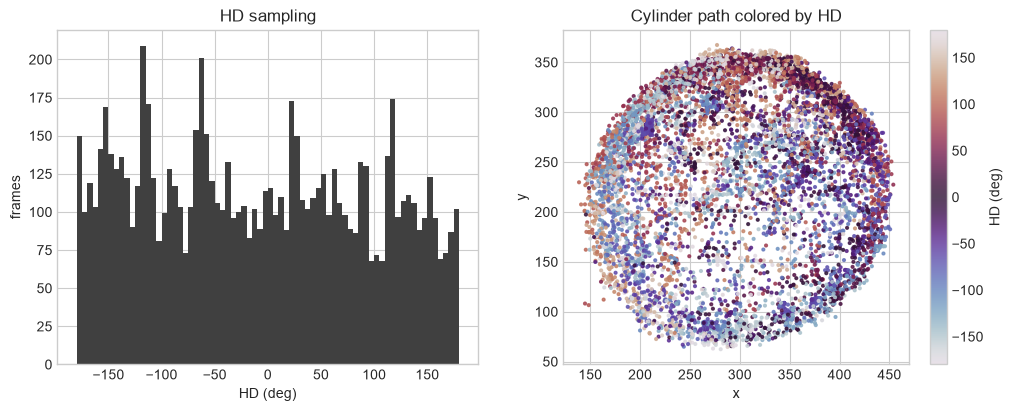

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
axes[0].hist(np.rad2deg(hd), bins=72, color="0.25")
axes[0].set_xlabel("HD (deg)")
axes[0].set_ylabel("frames")
axes[0].set_title("HD sampling")

sc = axes[1].scatter(coord[:, 0], coord[:, 1], s=4, c=np.rad2deg(hd), cmap="twilight", alpha=0.8)
axes[1].set_aspect("equal", adjustable="box")
axes[1].set_title("Cylinder path colored by HD")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

cbar = fig.colorbar(sc,ax=axes[1])
cbar.set_label("HD (deg)")

plt.show()

## Train/validation/test split

The training set fits model weights. The validation set selects the dropout rate and the best epoch. The test set is reserved for the final evaluation.


In [7]:
def temporal_split(n, train_frac=0.70, val_frac=0.15):
    train_end = int(n * train_frac)
    val_end = int(n * (train_frac + val_frac))
    return (
        np.arange(0, train_end),
        np.arange(train_end, val_end),
        np.arange(val_end, n),
    )


train_idx, val_idx, test_idx = temporal_split(len(hd))

# Fit z-score normalization using training frames only.
mu = X[train_idx].mean(axis=0, keepdims=True)
sigma = X[train_idx].std(axis=0, keepdims=True)
sigma[sigma == 0] = 1
Xz = (X - mu) / sigma

y = np.column_stack([np.cos(hd), np.sin(hd)]).astype(np.float32)

print(f"train frames: {len(train_idx):,}")
print(f"validation frames: {len(val_idx):,}")
print(f"test frames: {len(test_idx):,}")
print(f"Xz shape: {Xz.shape}")
print(f"y shape: {y.shape}")


train frames: 5,747
validation frames: 1,231
test frames: 1,232
Xz shape: (8210, 461)
y shape: (8210, 2)


In [8]:
class FrameHDDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.as_tensor(X, dtype=torch.float32)
        self.y = torch.as_tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


## Define the MLP and training helpers


In [9]:
class HDDecoderMLP(nn.Module):
    def __init__(self, n_cells, dropout_p=0.20):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_cells, 128),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2),
        )

    def forward(self, x):
        out = self.net(x)
        return nn.functional.normalize(out, dim=1)


loss_fn = nn.MSELoss()


def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss = 0.0
    n = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        with torch.set_grad_enabled(training):
            pred = model(xb)
            loss = loss_fn(pred, yb)

        if training:
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * len(xb)
        n += len(xb)

    return total_loss / n


def circular_mae_degrees(model, X_array, hd_array):
    pred_vec = predict_vectors(model, X_array)
    pred_hd = np.arctan2(pred_vec[:, 1], pred_vec[:, 0])
    valid = np.isfinite(pred_hd) & np.isfinite(hd_array)
    error = circular_difference(pred_hd[valid], hd_array[valid])
    return np.abs(np.rad2deg(error)).mean()


@torch.no_grad()
def predict_vectors(model, X_array, batch_size=1024):
    model.eval()
    predictions = []
    for start in range(0, len(X_array), batch_size):
        xb = torch.as_tensor(
            X_array[start:start + batch_size],
            dtype=torch.float32,
            device=device,
        )
        predictions.append(model(xb).cpu().numpy())
    return np.vstack(predictions)


## Tune the dropout rate

Every candidate uses the same training and validation frames. The model and optimizer are re-initialized for each candidate, so the comparison is between independent training runs.


In [13]:
DROPOUT_RATES = [0.0, 0.10, 0.20, 0.40, 0.60, 0.8, 0.9, 0.95, 0.99]
BATCH_SIZE = 256
MAX_EPOCHS = 200
PATIENCE = 20
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

candidate_results = []
candidate_histories = {}
candidate_states = {}

for dropout_p in DROPOUT_RATES:
    # Reset the random state so candidates start comparably.
    seed_everything(7)

    train_loader = DataLoader(
        FrameHDDataset(Xz[train_idx], y[train_idx]),
        batch_size=BATCH_SIZE,
        shuffle=True,
    )
    val_loader = DataLoader(
        FrameHDDataset(Xz[val_idx], y[val_idx]),
        batch_size=BATCH_SIZE,
        shuffle=False,
    )

    model = HDDecoderMLP(X.shape[1], dropout_p=dropout_p).to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    history = []
    best_val_loss = float("inf")
    best_state = None
    best_epoch = None
    bad_epochs = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss = run_epoch(model, train_loader, optimizer=optimizer)
        val_loss = run_epoch(model, val_loader)
        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "val_loss": val_loss,
            }
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= PATIENCE:
            break

    model.load_state_dict(best_state)
    val_mae_deg = circular_mae_degrees(model, Xz[val_idx], hd[val_idx])

    candidate_histories[dropout_p] = history
    candidate_states[dropout_p] = best_state
    candidate_results.append(
        {
            "dropout": dropout_p,
            "best_epoch": best_epoch,
            "best_val_mse": best_val_loss,
            "val_mae_deg": val_mae_deg,
            "epochs_run": len(history),
        }
    )

candidate_results_df = (
    pd.DataFrame(candidate_results)
    .sort_values("val_mae_deg")
    .reset_index(drop=True)
)
candidate_results_df


,dropout,best_epoch,best_val_mse,val_mae_deg,epochs_run
0,0.90,32,0.175129,27.405271,52
1,0.80,27,0.172351,27.428254,47
2,0.95,61,0.175562,27.627527,81
3,0.60,7,0.177556,27.996254,27
4,0.40,9,0.189486,29.130640,29
5,0.20,18,0.197766,29.759943,38
6,0.10,5,0.198259,29.882718,25
7,0.00,2,0.221940,32.050960,22
8,0.99,7,0.347403,43.014151,27


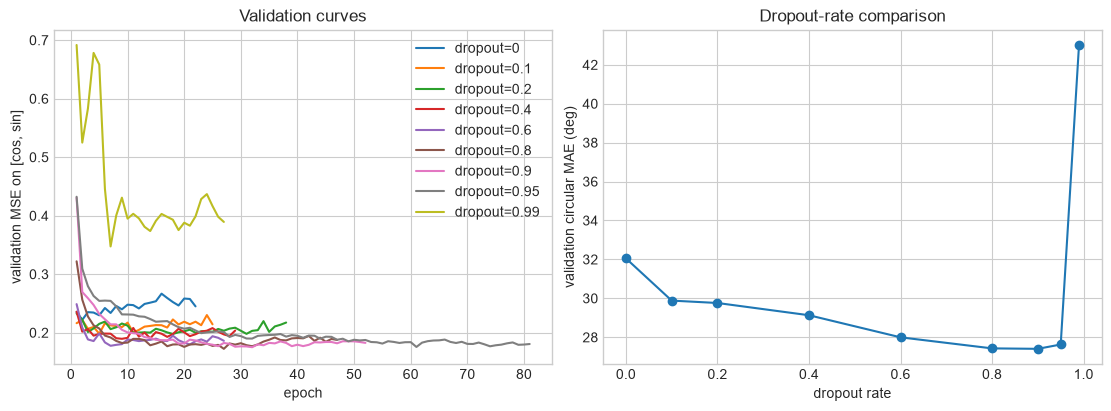

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

for dropout_p, history in candidate_histories.items():
    hist_candidate = pd.DataFrame(history)
    axes[0].plot(
        hist_candidate["epoch"],
        hist_candidate["val_loss"],
        label=f"dropout={dropout_p:g}",
    )

axes[0].set_xlabel("epoch")
axes[0].set_ylabel("validation MSE on [cos, sin]")
axes[0].set_title("Validation curves")
axes[0].legend()

plot_results_df = (
    pd.DataFrame(candidate_results)
    .sort_values("dropout")
    .reset_index(drop=True)
)
axes[1].plot(
    plot_results_df["dropout"],
    plot_results_df["val_mae_deg"],
    marker="o",
)
axes[1].set_xlabel("dropout rate")
axes[1].set_ylabel("validation circular MAE (deg)")
axes[1].set_title("Dropout-rate comparison")

plt.show()


## Select the dropout rate and evaluate on the test set

The dropout rate with the lowest validation circular MAE is selected. Only after this selection do we evaluate the corresponding best checkpoint on the test set.


In [17]:
best_row = candidate_results_df.loc[candidate_results_df["val_mae_deg"].idxmin()]
best_dropout = float(best_row["dropout"])

best_model = HDDecoderMLP(
    X.shape[1],
    dropout_p=best_dropout,
).to(device)
best_model.load_state_dict(candidate_states[best_dropout])
best_model.eval()

test_pred_vec = predict_vectors(best_model, Xz[test_idx])
test_pred_hd = np.arctan2(test_pred_vec[:, 1], test_pred_vec[:, 0])
test_actual_hd = hd[test_idx]

test_mask = np.isfinite(test_pred_hd) & np.isfinite(test_actual_hd)
test_err = circular_difference(
    test_pred_hd[test_mask],
    test_actual_hd[test_mask],
)
test_abs_err_deg = np.abs(np.rad2deg(test_err))

print(f"selected dropout rate: {best_dropout:g}")
print(f"selected validation MAE: {best_row['val_mae_deg']:.1f} deg")
print(f"valid test frames: {test_mask.sum():,}")
print(f"test mean absolute circular error: {test_abs_err_deg.mean():.1f} deg")
print(f"test median absolute circular error: {np.median(test_abs_err_deg):.1f} deg")


selected dropout rate: 0.9
selected validation MAE: 27.4 deg
valid test frames: 1,232
test mean absolute circular error: 32.1 deg
test median absolute circular error: 23.8 deg


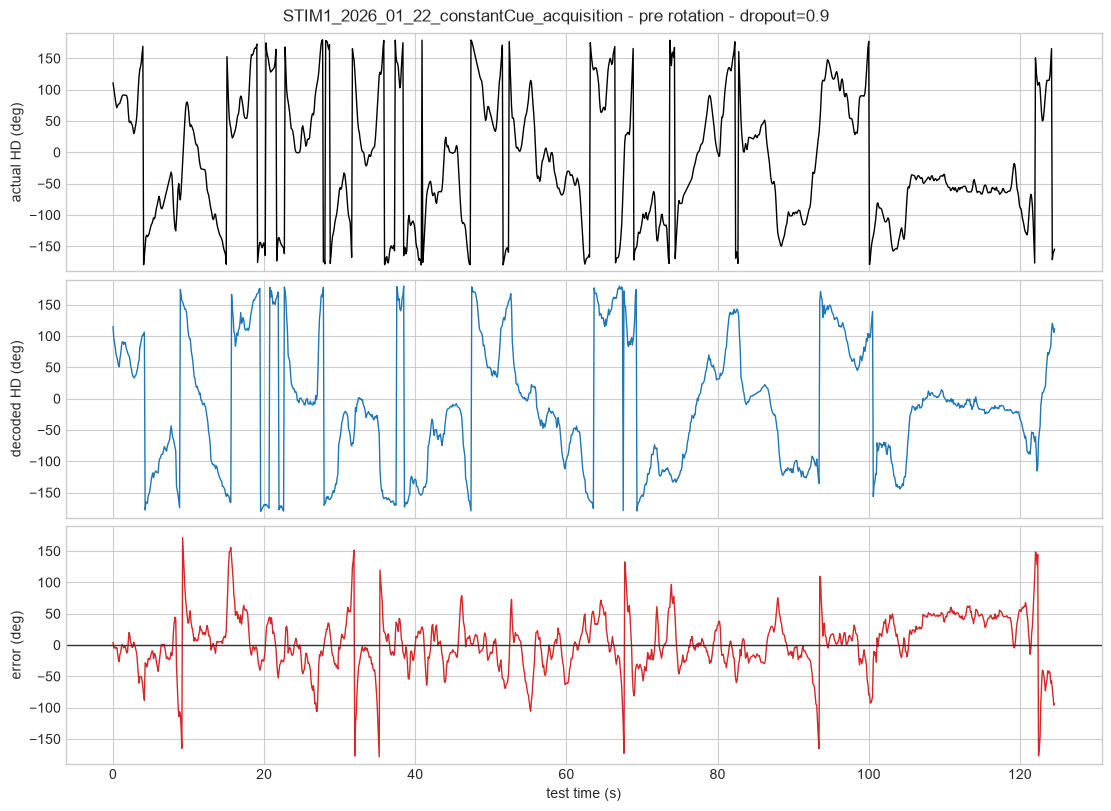

In [18]:
t_s = (time_ms[test_idx] - time_ms[test_idx][0]) / 1000

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True, constrained_layout=True)
axes[0].plot(t_s, np.rad2deg(test_actual_hd), lw=1, color="black")
axes[0].set_ylabel("actual HD (deg)")
axes[0].set_ylim(-190, 190)

axes[1].plot(t_s, np.rad2deg(test_pred_hd), lw=1, color="tab:blue")
axes[1].set_ylabel("decoded HD (deg)")
axes[1].set_ylim(-190, 190)

axes[2].plot(t_s[test_mask], np.rad2deg(test_err), lw=1, color="tab:red")
axes[2].axhline(0, color="0.2", lw=1)
axes[2].set_ylabel("error (deg)")
axes[2].set_xlabel("test time (s)")
axes[2].set_ylim(-190, 190)

fig.suptitle(
    f"{SESSION_NAME} - {WINDOW_NAMES[WINDOW_INDEX]} - "
    f"dropout={best_dropout:g}"
)
plt.show()


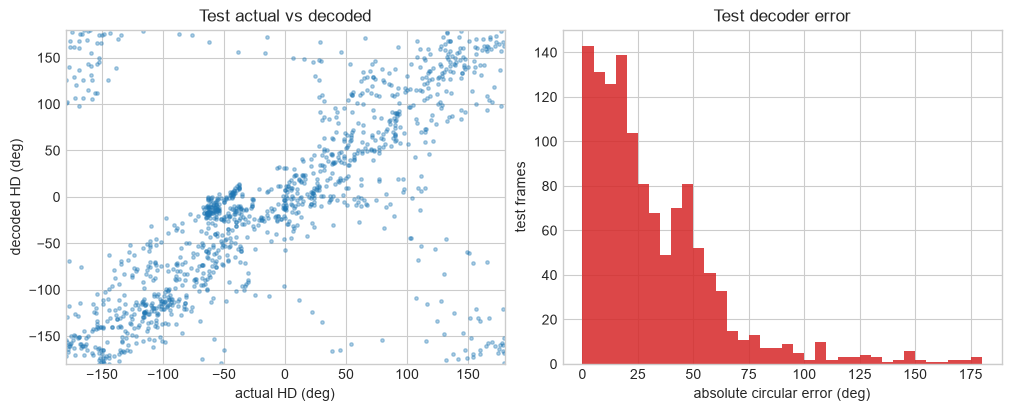

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

axes[0].scatter(
    np.rad2deg(test_actual_hd[test_mask]),
    np.rad2deg(test_pred_hd[test_mask]),
    s=6,
    alpha=0.35,
)
axes[0].set_xlim(-180, 180)
axes[0].set_ylim(-180, 180)
axes[0].set_xlabel("actual HD (deg)")
axes[0].set_ylabel("decoded HD (deg)")
axes[0].set_title("Test actual vs decoded")

axes[1].hist(
    test_abs_err_deg,
    bins=np.arange(0, 185, 5),
    color="tab:red",
    alpha=0.85,
)
axes[1].set_xlabel("absolute circular error (deg)")
axes[1].set_ylabel("test frames")
axes[1].set_title("Test decoder error")

plt.show()


## Important interpretation

The validation set has been used to choose both the dropout rate and the best epoch for each candidate. Therefore, the test error is the appropriate final estimate for this tuned model. Do not use the test error to choose another dropout rate without creating a new untouched test set.
